# Introduction 

* Dataset used: Global Findex for Philippines
* Years included: 2021
* Kind of data: observation/ratings
* Unit of analysis: individual
* Link to dataset and more info: https://microdata.worldbank.org/index.php/catalog/4695/study-description

# Importing the libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score,roc_curve,auc,log_loss,confusion_matrix
from sklearn import metrics

In [2]:
pd.set_option('display.max_rows', None)

# Fetching the data

In [3]:
data = pd.read_csv(r"C:\Users\Evgenia\Downloads\philippines_df.csv")

data.head()

,Unnamed: 0,economy,wgt,female,age,educ,inc_q,emp_in,urbanicity_f2f,account,...,receive_transfers,receive_pension,receive_agriculture,pay_utilities,remittances,mobileowner,internetaccess,anydigpayment,merchantpay_dig,year
0,104794,Philippines,0.315484,1,18.0,2,2,2.0,NaN,0,...,4,4,4.0,4,5.0,2,1,0,0.0,2021
1,104795,Philippines,1.565440,2,30.0,2,4,1.0,NaN,1,...,4,4,4.0,2,5.0,1,1,1,0.0,2021
2,104796,Philippines,2.015322,2,61.0,2,2,1.0,NaN,1,...,1,1,4.0,4,1.0,1,2,1,0.0,2021
3,104797,Philippines,0.266541,1,36.0,2,2,2.0,NaN,1,...,4,4,4.0,3,5.0,1,1,0,0.0,2021
4,104798,Philippines,1.073062,2,45.0,3,4,1.0,NaN,1,...,2,4,4.0,2,5.0,1,1,0,0.0,2021


# Data cleansing and initial exploration

### Number of rows and columns

In [4]:
data.shape

(1000, 125)

### Column names

In [5]:
column_list = data.columns.tolist()
column_list

['Unnamed: 0',
 'economy',
 'wgt',
 'female',
 'age',
 'educ',
 'inc_q',
 'emp_in',
 'urbanicity_f2f',
 'account',
 'account_fin',
 'account_mob',
 'fin1_1a',
 'fin1_1b',
 'fin2',
 'fin4',
 'fin4a',
 'fin5',
 'fin6',
 'fin7',
 'fin8',
 'fin8a',
 'fin8b',
 'fin9',
 'fin9a',
 'fin10',
 'fin10_1a',
 'fin10_1b',
 'fin10_1c',
 'fin10_1d',
 'fin10_1e',
 'fin10a',
 'fin10b',
 'fin11_1',
 'fin11a',
 'fin11b',
 'fin11c',
 'fin11d',
 'fin11e',
 'fin11f',
 'fin11g',
 'fin11h',
 'fin13_1a',
 'fin13_1b',
 'fin13_1c',
 'fin13_1d',
 'fin13_1e',
 'fin13_1f',
 'fin13a',
 'fin13b',
 'fin13c',
 'fin13d',
 'fin14_1',
 'fin14_2',
 'fin14_2_China',
 'fin14a',
 'fin14a1',
 'fin14b',
 'fin14c',
 'fin14c_2',
 'fin14c_2_China',
 'fin16',
 'fin17a',
 'fin17a1',
 'fin17b',
 'fin20',
 'fin22a',
 'fin22b',
 'fin22c',
 'fin24',
 'fin24a',
 'fin24b',
 'fin26',
 'fin27_1',
 'fin27c1',
 'fin27c2',
 'fin28',
 'fin29_1',
 'fin29c1',
 'fin29c2',
 'fin30',
 'fin31a',
 'fin31b',
 'fin31b1',
 'fin31b1_China',
 'fin31c',
 'fi

### Columns renamed

In [6]:
data = data.rename(columns = {'female':'Sex','Unnamed: 0':'Respondent ID'})

### Check for unique respondent IDs

In [7]:
# All of the IDs are unique as they match the df's rows
data["Respondent ID"].nunique()

1000

### View data summary (relevant only for columns with continuous and not categorical values, i.e. age and not sex)

In [8]:
data.describe()

,Respondent ID,wgt,Sex,age,educ,inc_q,emp_in,urbanicity_f2f,account,account_fin,...,receive_transfers,receive_pension,receive_agriculture,pay_utilities,remittances,mobileowner,internetaccess,anydigpayment,merchantpay_dig,year
count,1000.000000,1000.000000,1000.00000,999.000000,1000.000000,1000.000000,1000.000000,0.0,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0
mean,105293.500000,1.000000,1.42700,32.963964,2.128000,3.372000,1.293000,NaN,0.627000,0.564000,...,3.304000,3.890000,3.686000,2.473000,3.210000,1.037000,1.126000,0.547000,0.263000,2021.0
std,288.819436,0.908511,0.49489,12.620430,0.638768,1.410534,0.455366,NaN,0.483844,0.496135,...,1.062409,0.512018,0.796265,1.170744,1.740382,0.188856,0.332015,0.498035,0.440483,0.0
min,104794.000000,0.168433,1.00000,15.000000,1.000000,1.000000,1.000000,NaN,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,2021.0
25%,105043.750000,0.344517,1.00000,23.000000,2.000000,2.000000,1.000000,NaN,0.000000,0.000000,...,2.000000,4.000000,4.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,2021.0
50%,105293.500000,0.682144,1.00000,31.000000,2.000000,4.000000,1.000000,NaN,1.000000,1.000000,...,4.000000,4.000000,4.000000,2.000000,3.000000,1.000000,1.000000,1.000000,0.000000,2021.0
75%,105543.250000,1.290406,2.00000,40.000000,3.000000,5.000000,2.000000,NaN,1.000000,1.000000,...,4.000000,4.000000,4.000000,4.000000,5.000000,1.000000,1.000000,1.000000,1.000000,2021.0
max,105793.000000,3.590342,2.00000,87.000000,3.000000,5.000000,2.000000,NaN,1.000000,1.000000,...,4.000000,4.000000,4.000000,4.000000,5.000000,2.000000,2.000000,1.000000,1.000000,2021.0


### Checking for missing values

In [9]:
missing_data = data.isnull().any()
missing_data

Respondent ID          False
economy                False
wgt                    False
Sex                    False
age                     True
educ                   False
inc_q                  False
emp_in                 False
urbanicity_f2f          True
account                False
account_fin            False
account_mob            False
fin1_1a                 True
fin1_1b                 True
fin2                   False
fin4                    True
fin4a                   True
fin5                    True
fin6                    True
fin7                    True
fin8                    True
fin8a                   True
fin8b                   True
fin9                    True
fin9a                   True
fin10                   True
fin10_1a                True
fin10_1b                True
fin10_1c                True
fin10_1d                True
fin10_1e                True
fin10a                  True
fin10b                  True
fin11_1                 True
fin11a        

In [10]:
# Quite a few columns from above have missing values - checking the percentage of missing values per column

missing_perc = data.isnull().sum()/data.shape[0]
missing_perc

Respondent ID          0.000
economy                0.000
wgt                    0.000
Sex                    0.000
age                    0.001
educ                   0.000
inc_q                  0.000
emp_in                 0.000
urbanicity_f2f         1.000
account                0.000
account_fin            0.000
account_mob            0.000
fin1_1a                0.562
fin1_1b                0.562
fin2                   0.000
fin4                   0.612
fin4a                  0.808
fin5                   0.504
fin6                   0.504
fin7                   0.504
fin8                   0.881
fin8a                  0.908
fin8b                  0.881
fin9                   0.504
fin9a                  0.658
fin10                  0.504
fin10_1a               1.000
fin10_1b               1.000
fin10_1c               1.000
fin10_1d               1.000
fin10_1e               1.000
fin10a                 0.648
fin10b                 0.504
fin11_1                0.627
fin11a        

In [11]:
# Dropping all the columns with 20% or more missing values

columns_to_drop = missing_perc[missing_perc > 0.2].index
data_after_first_cleansing = data.drop(columns_to_drop,axis=1)
data_after_first_cleansing

,Respondent ID,economy,wgt,Sex,age,educ,inc_q,emp_in,account,account_fin,...,receive_transfers,receive_pension,receive_agriculture,pay_utilities,remittances,mobileowner,internetaccess,anydigpayment,merchantpay_dig,year
0,104794,Philippines,0.315484,1,18.0,2,2,2.0,0,0,...,4,4,4.0,4,5.0,2,1,0,0.0,2021
1,104795,Philippines,1.565440,2,30.0,2,4,1.0,1,1,...,4,4,4.0,2,5.0,1,1,1,0.0,2021
2,104796,Philippines,2.015322,2,61.0,2,2,1.0,1,1,...,1,1,4.0,4,1.0,1,2,1,0.0,2021
3,104797,Philippines,0.266541,1,36.0,2,2,2.0,1,1,...,4,4,4.0,3,5.0,1,1,0,0.0,2021
4,104798,Philippines,1.073062,2,45.0,3,4,1.0,1,1,...,2,4,4.0,2,5.0,1,1,0,0.0,2021
5,104799,Philippines,0.725511,2,24.0,3,2,1.0,0,0,...,2,4,2.0,4,2.0,1,1,0,0.0,2021
6,104800,Philippines,0.619914,1,30.0,2,1,2.0,0,0,...,4,4,4.0,2,5.0,1,1,0,0.0,2021
7,104801,Philippines,3.590342,1,15.0,1,3,2.0,0,0,...,4,4,4.0,4,5.0,1,1,0,0.0,2021
8,104802,Philippines,1.238358,2,27.0,2,1,1.0,1,1,...,4,4,4.0,1,5.0,1,1,1,1.0,2021
9,104803,Philippines,1.238358,2,31.0,3,3,1.0,1,1,...,4,4,4.0,1,5.0,1,1,1,1.0,2021


In [34]:
# Dropping further the columns which do not add to our analysis

data_after_second_cleansing = data_after_first_cleansing.drop(['Respondent ID','economy','year'],axis=1)
data_after_second_cleansing

,wgt,Sex,age,educ,inc_q,emp_in,account,account_fin,account_mob,fin2,...,receive_wages,receive_transfers,receive_pension,receive_agriculture,pay_utilities,remittances,mobileowner,internetaccess,anydigpayment,merchantpay_dig
0,0.315484,1,18.0,2,2,2.0,0,0,0.0,2,...,4,4,4,4.0,4,5.0,2,1,0,0.0
1,1.565440,2,30.0,2,4,1.0,1,1,0.0,2,...,1,4,4,4.0,2,5.0,1,1,1,0.0
2,2.015322,2,61.0,2,2,1.0,1,1,1.0,2,...,4,1,1,4.0,4,1.0,1,2,1,0.0
3,0.266541,1,36.0,2,2,2.0,1,1,0.0,1,...,4,4,4,4.0,3,5.0,1,1,0,0.0
4,1.073062,2,45.0,3,4,1.0,1,1,0.0,2,...,2,2,4,4.0,2,5.0,1,1,0,0.0
5,0.725511,2,24.0,3,2,1.0,0,0,0.0,2,...,4,2,4,2.0,4,2.0,1,1,0,0.0
6,0.619914,1,30.0,2,1,2.0,0,0,0.0,2,...,4,4,4,4.0,2,5.0,1,1,0,0.0
7,3.590342,1,15.0,1,3,2.0,0,0,0.0,2,...,4,4,4,4.0,4,5.0,1,1,0,0.0
8,1.238358,2,27.0,2,1,1.0,1,1,1.0,1,...,4,4,4,4.0,1,5.0,1,1,1,1.0
9,1.238358,2,31.0,3,3,1.0,1,1,1.0,1,...,4,4,4,4.0,1,5.0,1,1,1,1.0


In [13]:
# Checking again the % of missing values in the new df - Only fin45_1 has about 11% missing values

missing_perc = data_after_second_cleansing.isnull().sum()/data.shape[0]
missing_perc

Sex                    0.000
age                    0.001
educ                   0.000
inc_q                  0.000
emp_in                 0.000
account                0.000
account_fin            0.000
account_mob            0.000
fin2                   0.000
fin14_1                0.000
fin14a                 0.000
fin14a1                0.000
fin14b                 0.000
fin16                  0.000
fin17a                 0.000
fin17b                 0.000
fin20                  0.000
fin22a                 0.000
fin22b                 0.000
fin24                  0.000
fin24a                 0.007
fin24b                 0.007
fin26                  0.000
fin28                  0.000
fin30                  0.000
fin32                  0.000
fin37                  0.000
fin38                  0.000
fin42                  0.000
fin44a                 0.000
fin44b                 0.000
fin44c                 0.000
fin44d                 0.000
fin45                  0.110
fin45_1       

# Plotting

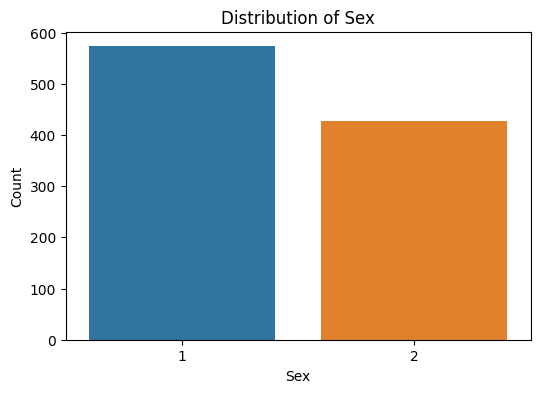

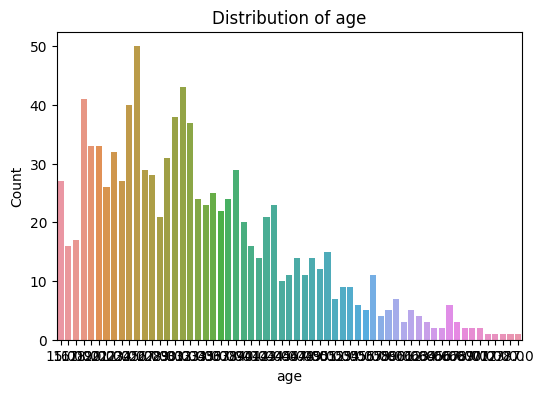

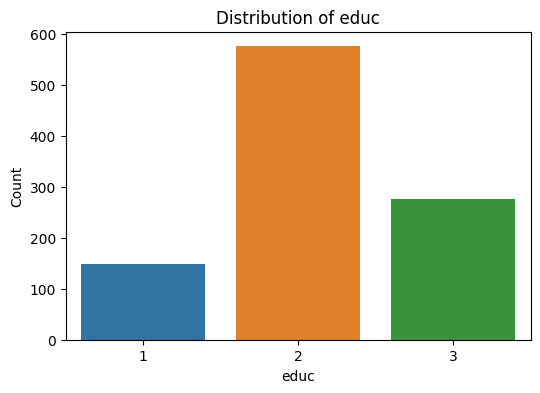

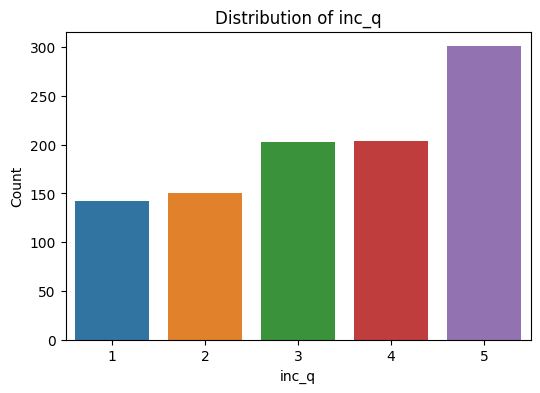

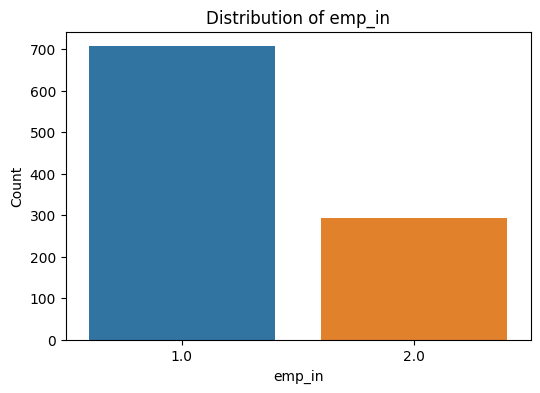

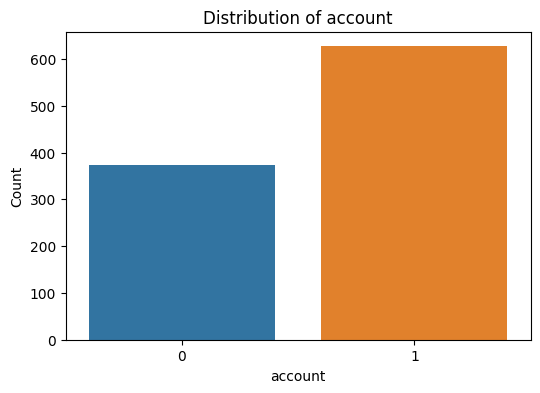

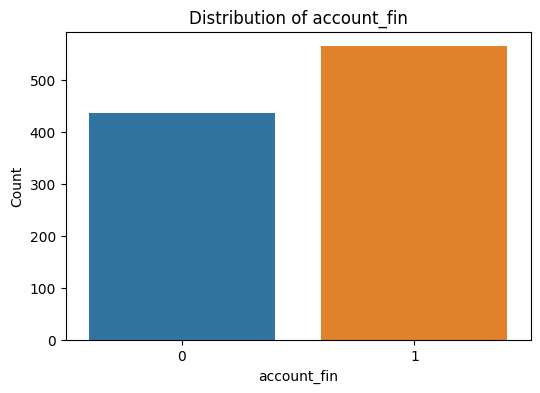

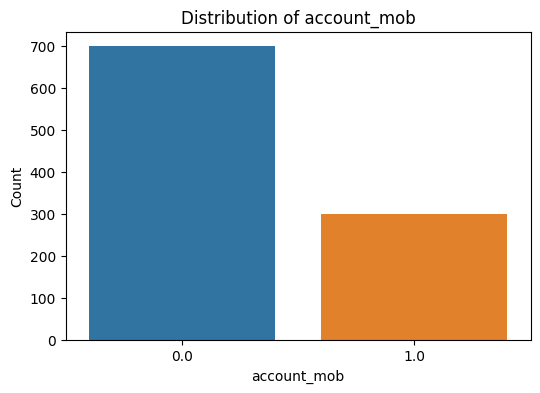

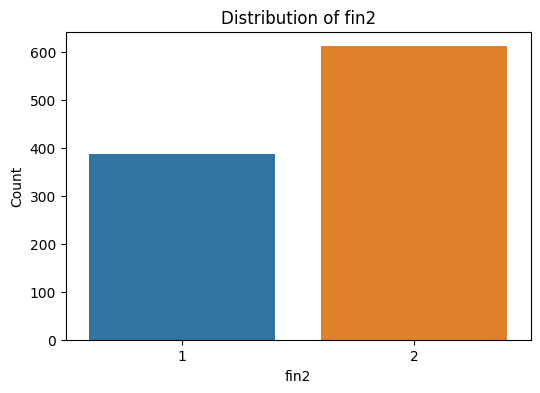

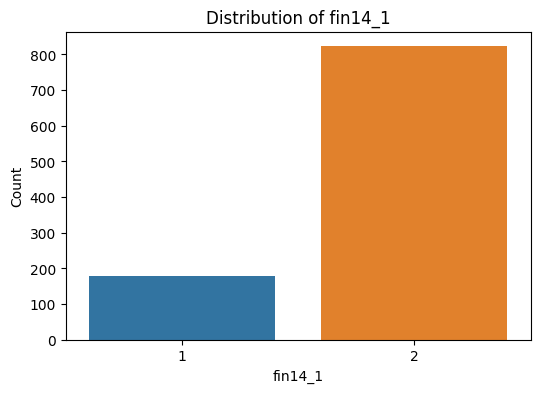

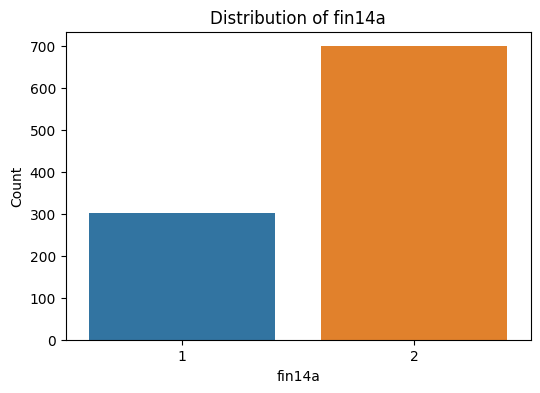

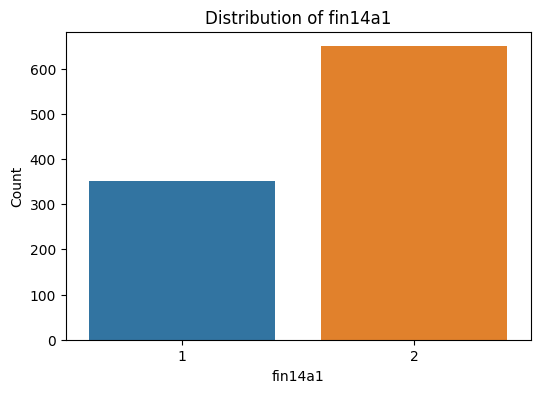

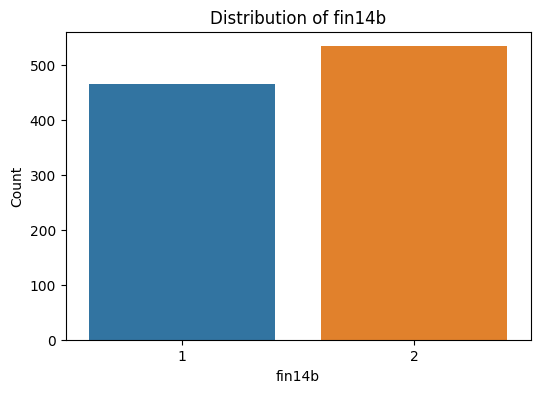

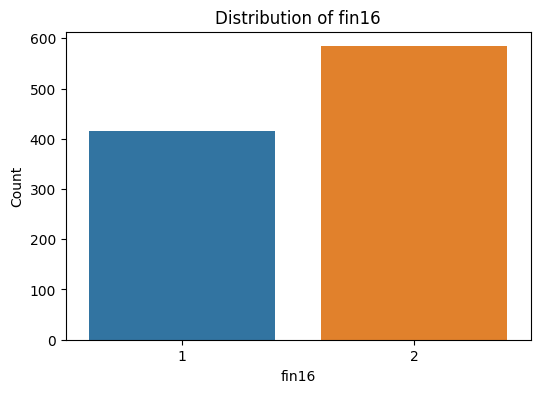

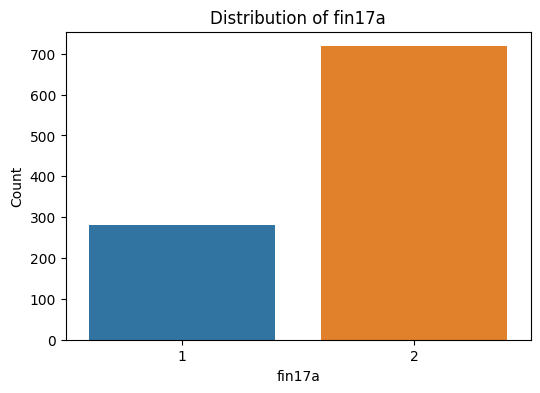

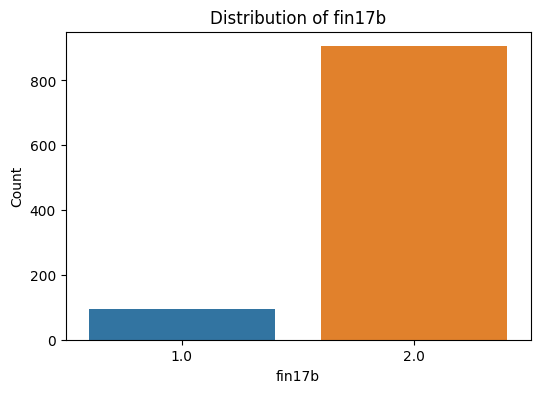

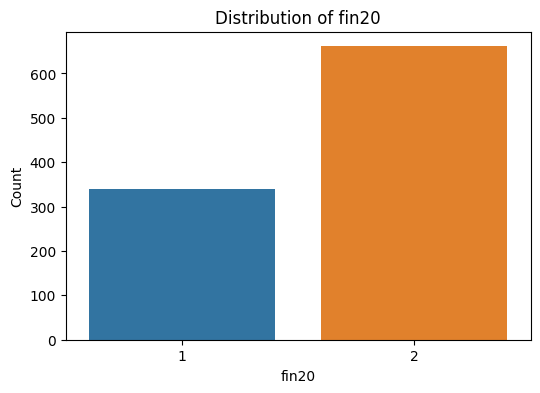

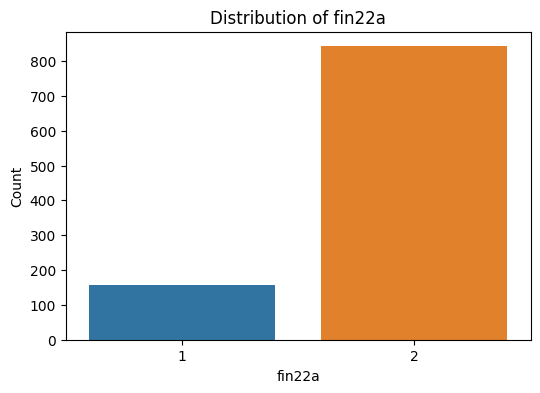

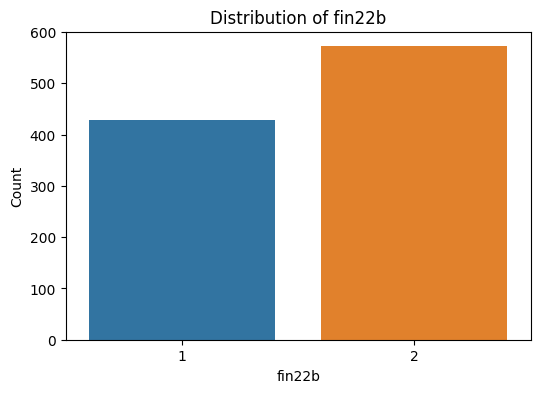

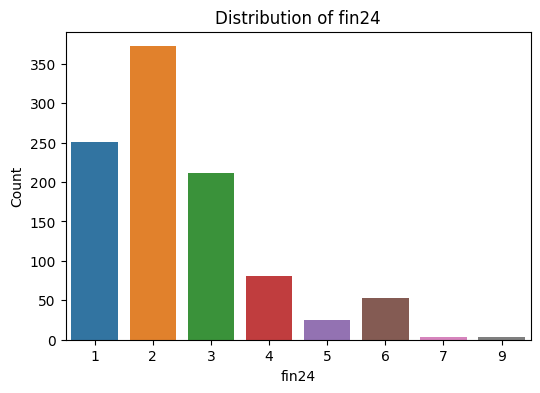

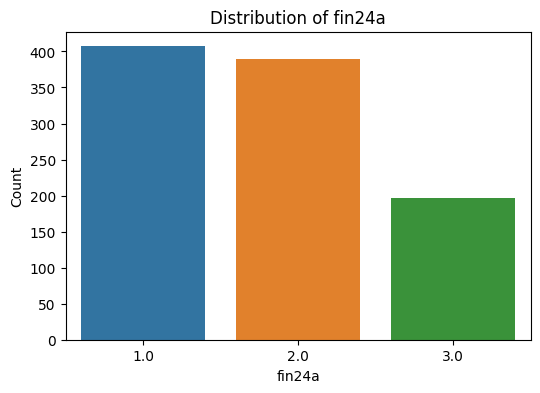

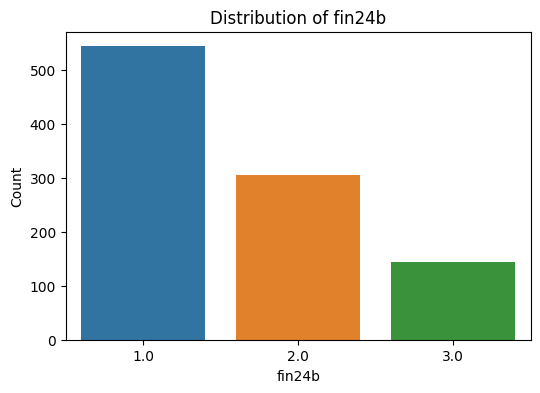

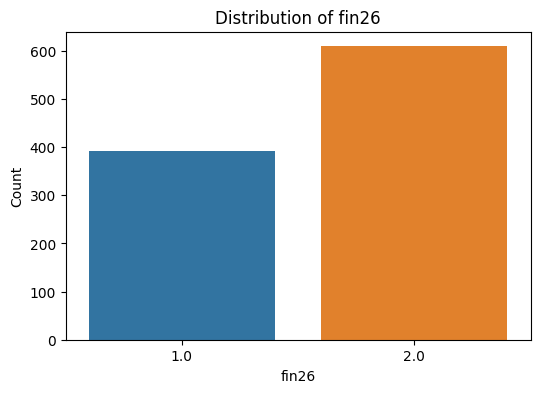

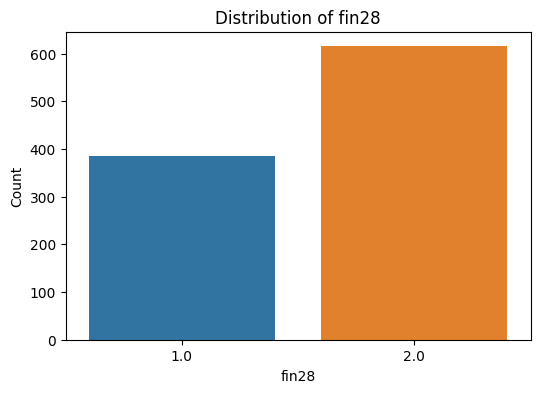

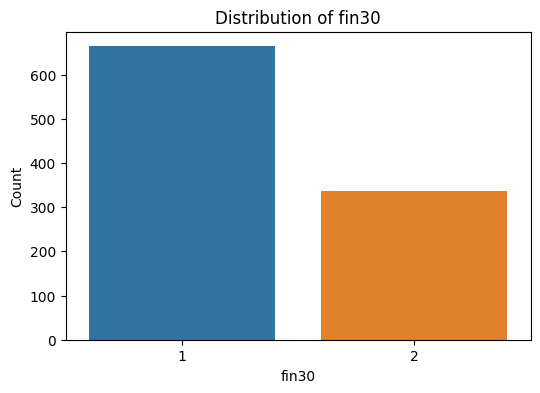

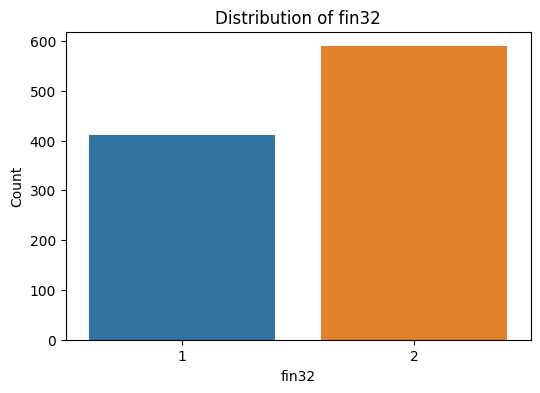

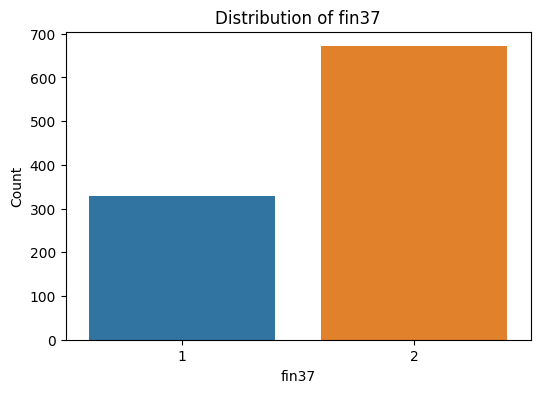

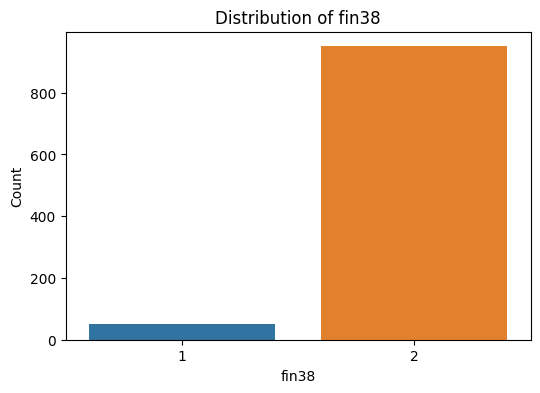

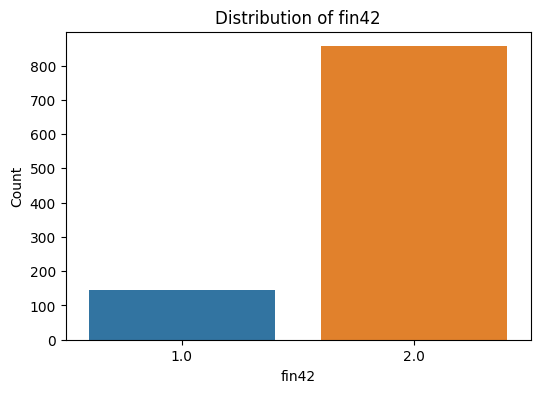

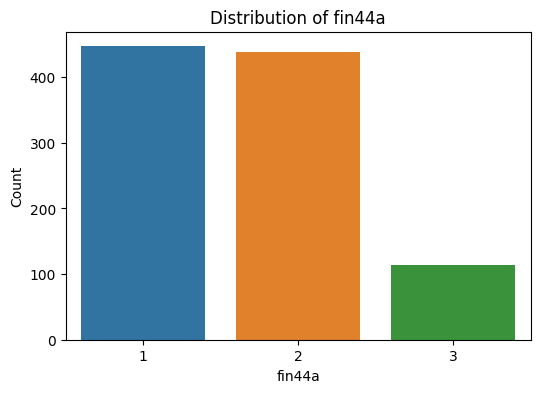

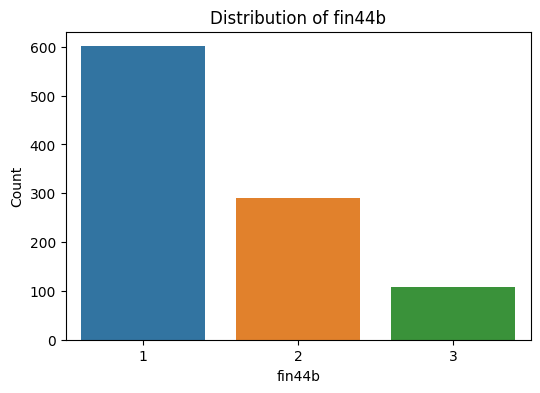

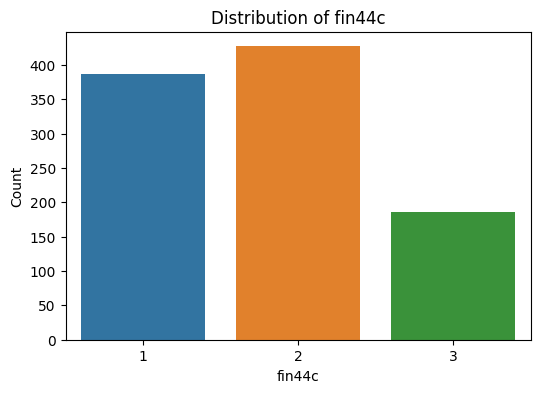

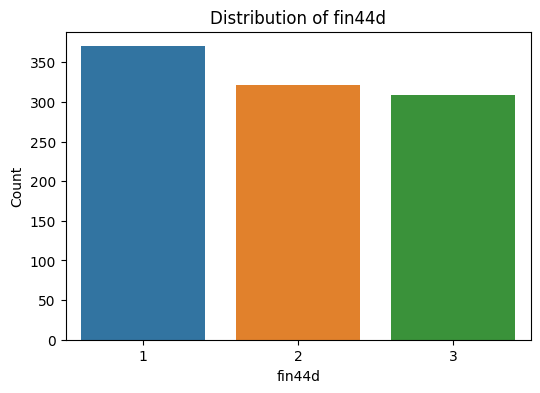

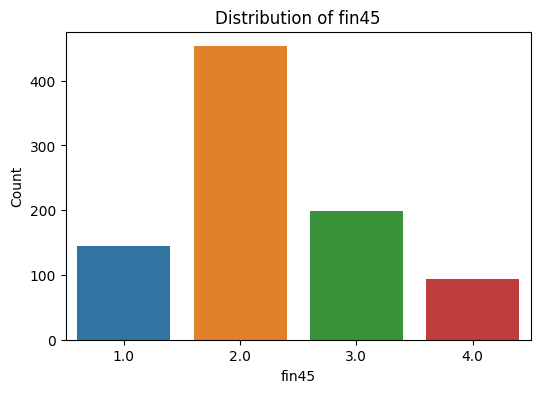

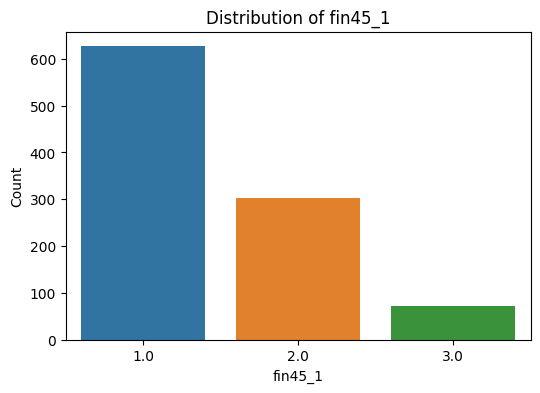

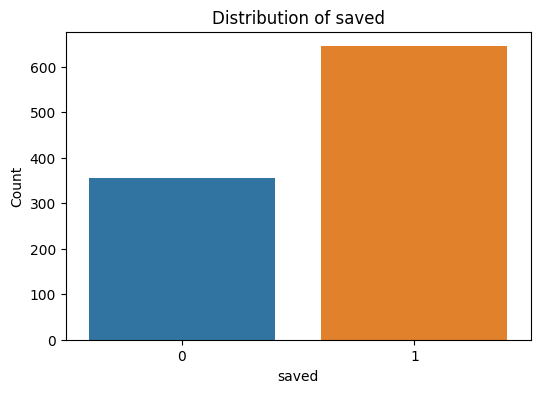

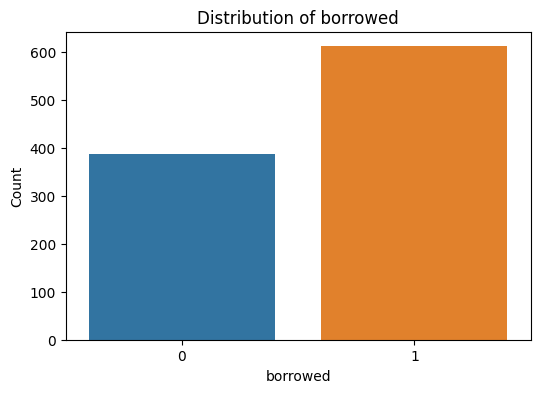

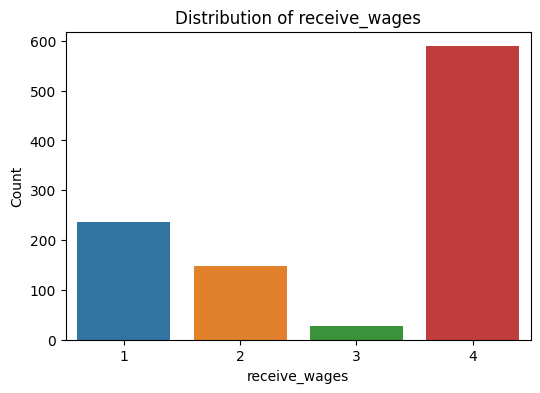

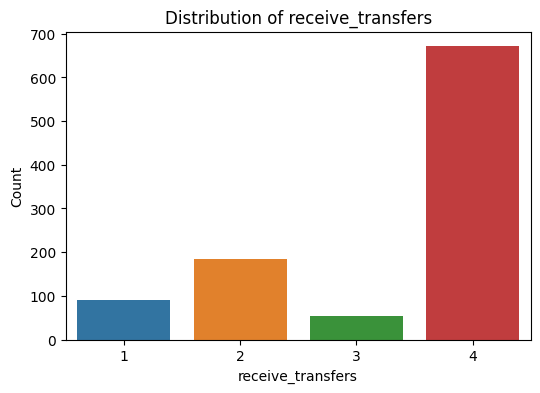

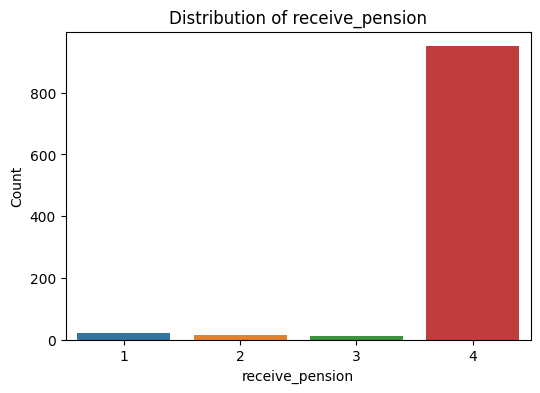

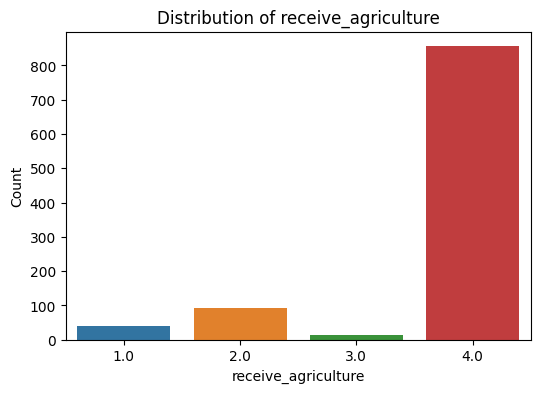

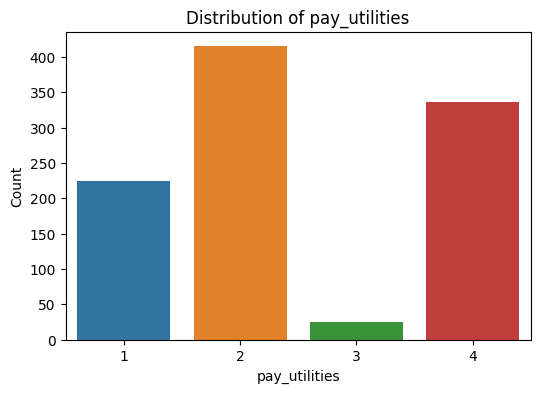

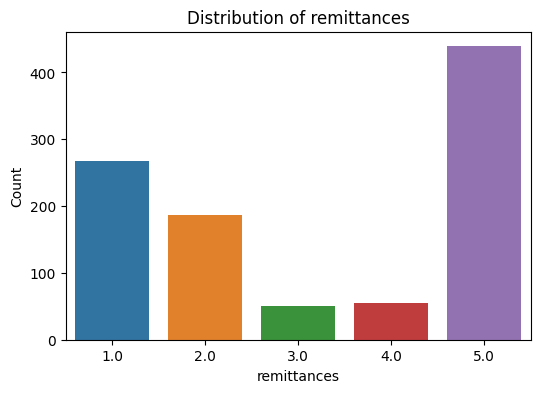

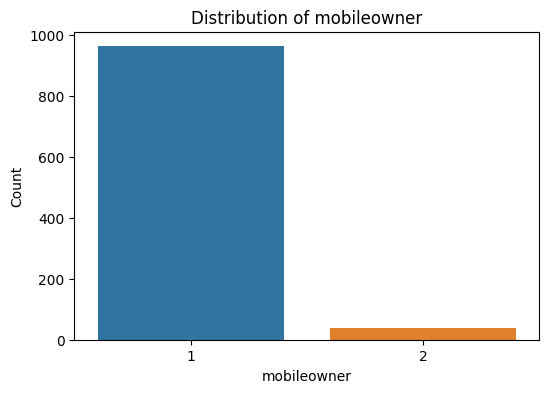

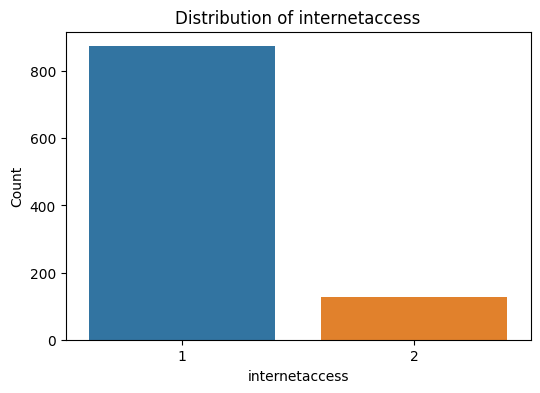

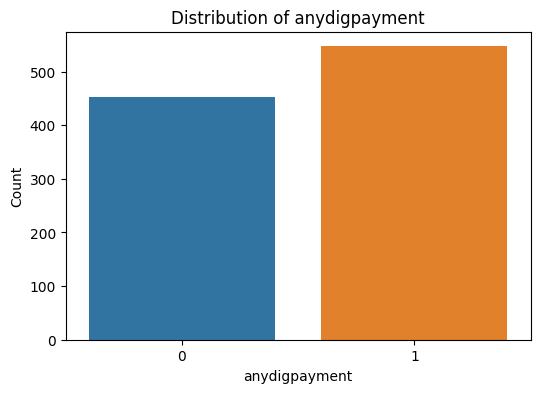

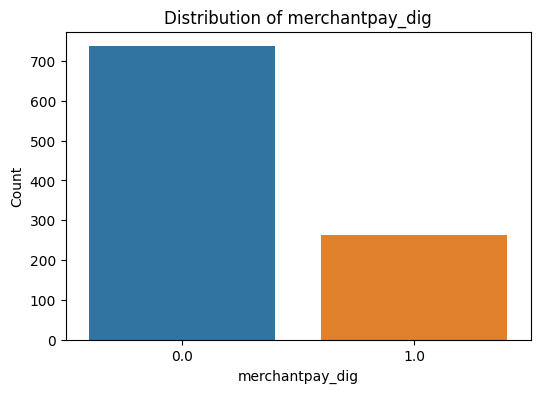

In [14]:
# Plotting each variable

for i in data_after_second_cleansing.columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=data, x=i)
    plt.title('Distribution of ' +i)
    plt.xlabel(i)
    plt.ylabel('Count')
    plt.show()

### Selecting a few key financial inclusion proxies based on the initial project description (and the availability of data)

* Account Ownership: Number of adults (15+) with an account at a financial institution or mobile money provider.
* Mobile Money Usage: Number of adults using mobile money accounts for transactions.
* Savings Behavior: Number of adults who saved money in the past year (formal or informal).
* Borrowing Behavior: Number of adults who borrowed money in the past year (formal or informal)
* Remittances Received: Number of adults receiving remittances from abroad.
* Social Protection Coverage: Number of population covered by social protection systems (pensions, social assistance, etc.).
* Internet Access: Number of adults with access to the internet.

#### As well as a few key demographics variables

* Sex
* Age
* Education
* Employment


In [27]:
key_variables_list = ['account','account_mob','saved','borrowed','remittances','receive_pension','receive_transfers',
                     'internetaccess','Sex','age','educ','emp_in']

In [28]:
data_with_key_var = data_after_second_cleansing[key_variables_list]
data_with_key_var

,account,account_mob,saved,borrowed,remittances,receive_pension,receive_transfers,internetaccess,Sex,age,educ,emp_in
0,0,0.0,1,0,5.0,4,4,1,1,18.0,2,2.0
1,1,0.0,0,0,5.0,4,4,1,2,30.0,2,1.0
2,1,1.0,0,1,1.0,1,1,2,2,61.0,2,1.0
3,1,0.0,1,1,5.0,4,4,1,1,36.0,2,2.0
4,1,0.0,1,0,5.0,4,2,1,2,45.0,3,1.0
5,0,0.0,1,1,2.0,4,2,1,2,24.0,3,1.0
6,0,0.0,1,1,5.0,4,4,1,1,30.0,2,2.0
7,0,0.0,0,0,5.0,4,4,1,1,15.0,1,2.0
8,1,1.0,1,1,5.0,4,4,1,2,27.0,2,1.0
9,1,1.0,1,1,5.0,4,4,1,2,31.0,3,1.0


### Correlation table

In [29]:
correlation_table = data_with_key_var.corr()
correlation_table

,account,account_mob,saved,borrowed,remittances,receive_pension,receive_transfers,internetaccess,Sex,age,educ,emp_in
account,1.000000,0.504931,0.309343,0.119988,-0.359794,-0.084973,-0.106339,-0.211873,0.076381,0.055708,0.365157,-0.148615
account_mob,0.504931,1.000000,0.275900,0.140614,-0.372580,0.034112,-0.060007,-0.209111,0.083380,-0.045044,0.306248,-0.119384
saved,0.309343,0.275900,1.000000,0.206967,-0.336926,0.007963,-0.033614,-0.222111,0.010921,-0.079882,0.246935,-0.146862
borrowed,0.119988,0.140614,0.206967,1.000000,-0.250715,0.021333,-0.168226,-0.118188,0.015251,-0.075708,0.018206,-0.073566
remittances,-0.359794,-0.372580,-0.336926,-0.250715,1.000000,0.038305,0.114317,0.205351,-0.057727,-0.016571,-0.225898,0.101640
receive_pension,-0.084973,0.034112,0.007963,0.021333,0.038305,1.000000,0.227151,-0.053819,0.007782,-0.213570,0.012487,-0.011892
receive_transfers,-0.106339,-0.060007,-0.033614,-0.168226,0.114317,0.227151,1.000000,0.067245,0.015596,-0.093244,0.000130,0.012266
internetaccess,-0.211873,-0.209111,-0.222111,-0.118188,0.205351,-0.053819,0.067245,1.000000,0.019483,0.211192,-0.264919,-0.019320
Sex,0.076381,0.083380,0.010921,0.015251,-0.057727,0.007782,0.015596,0.019483,1.000000,0.128423,0.080252,-0.209261
age,0.055708,-0.045044,-0.079882,-0.075708,-0.016571,-0.213570,-0.093244,0.211192,0.128423,1.000000,0.068836,-0.122264


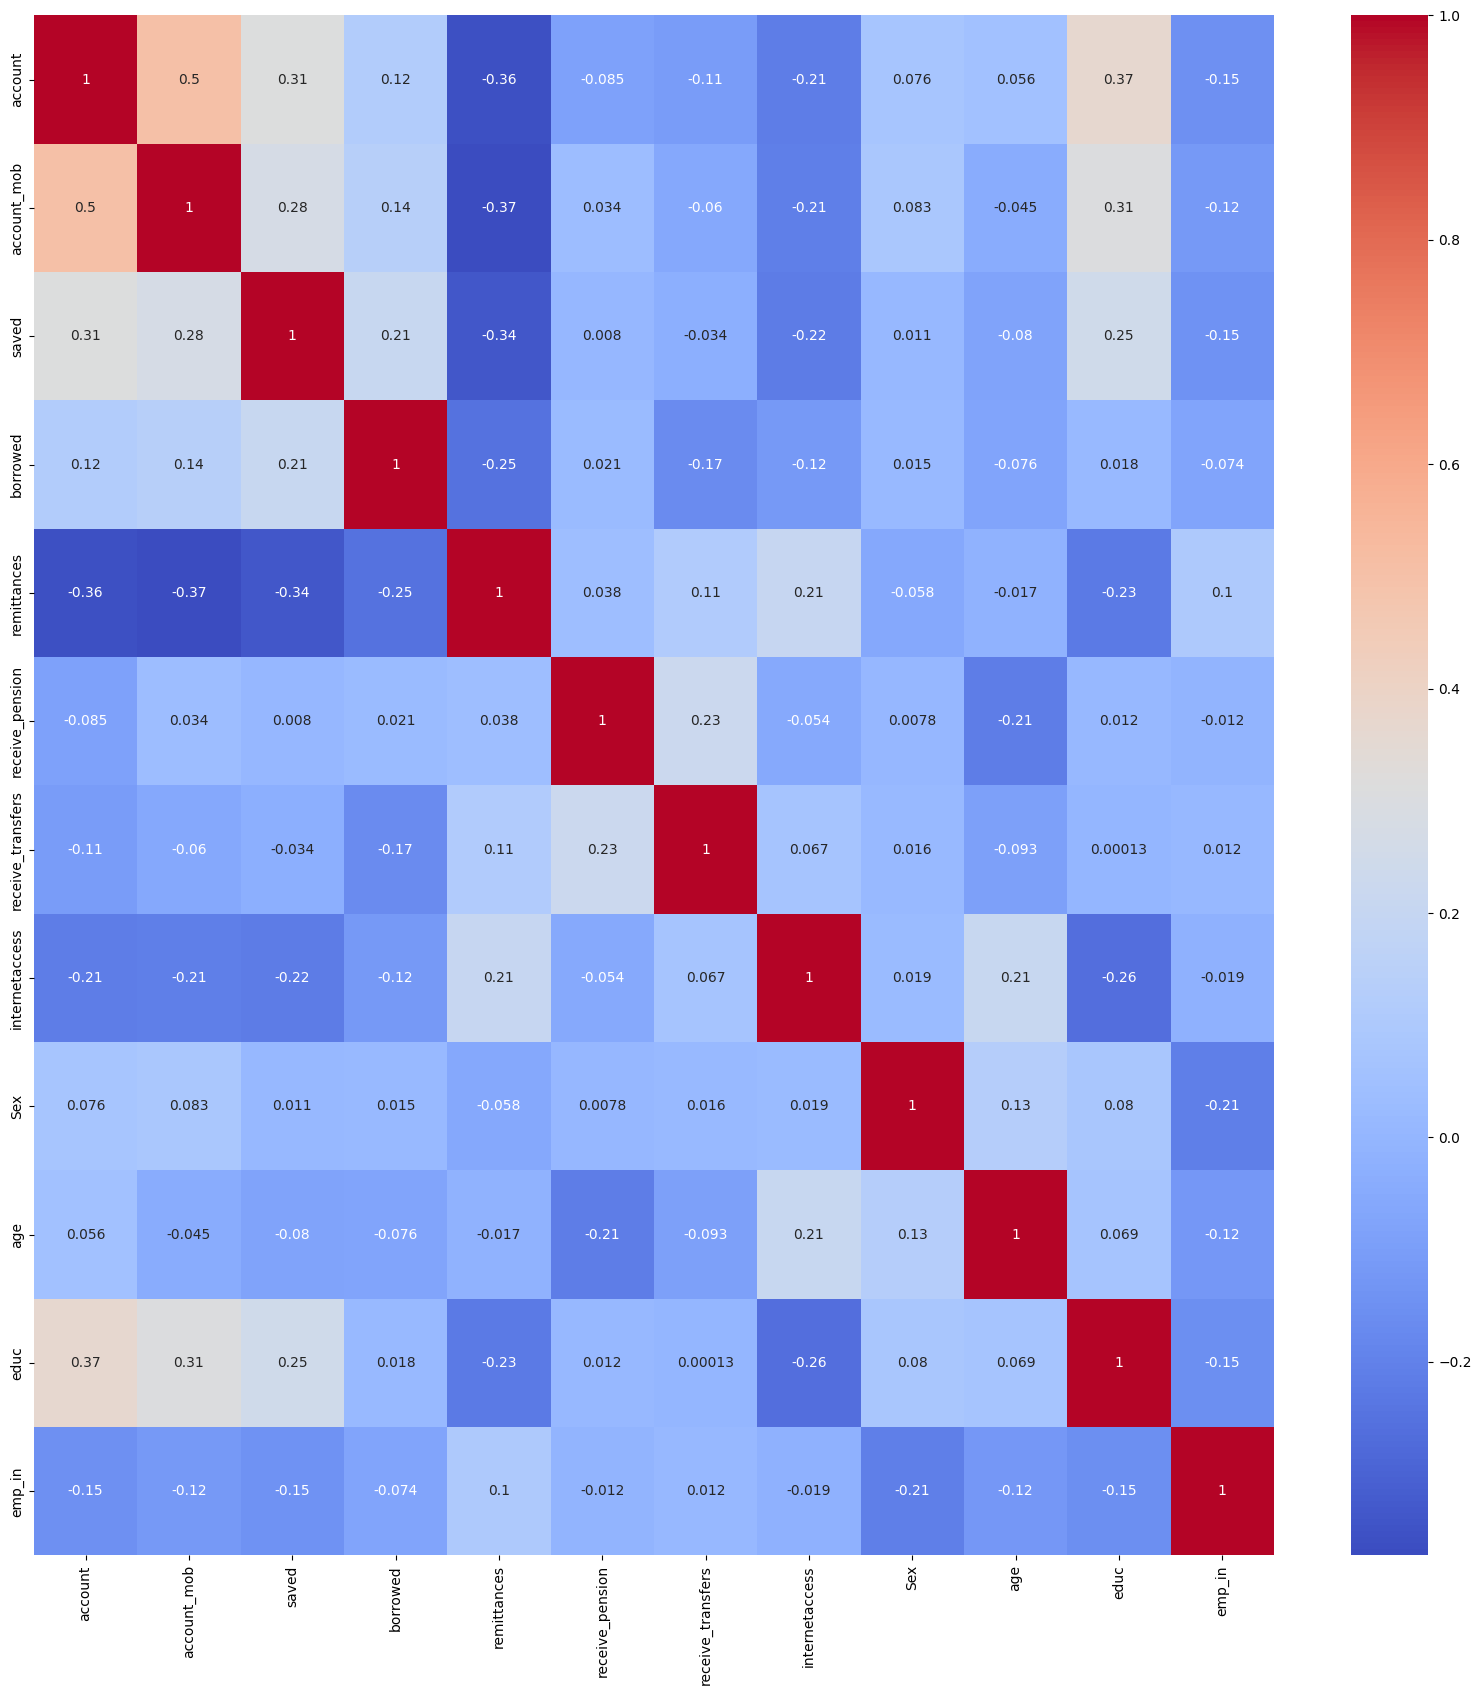

In [31]:
plt.figure(figsize=(20,20))
sns.heatmap(correlation_table, cmap='coolwarm',annot=True)
plt.show()

<Figure size 2000x2000 with 0 Axes>

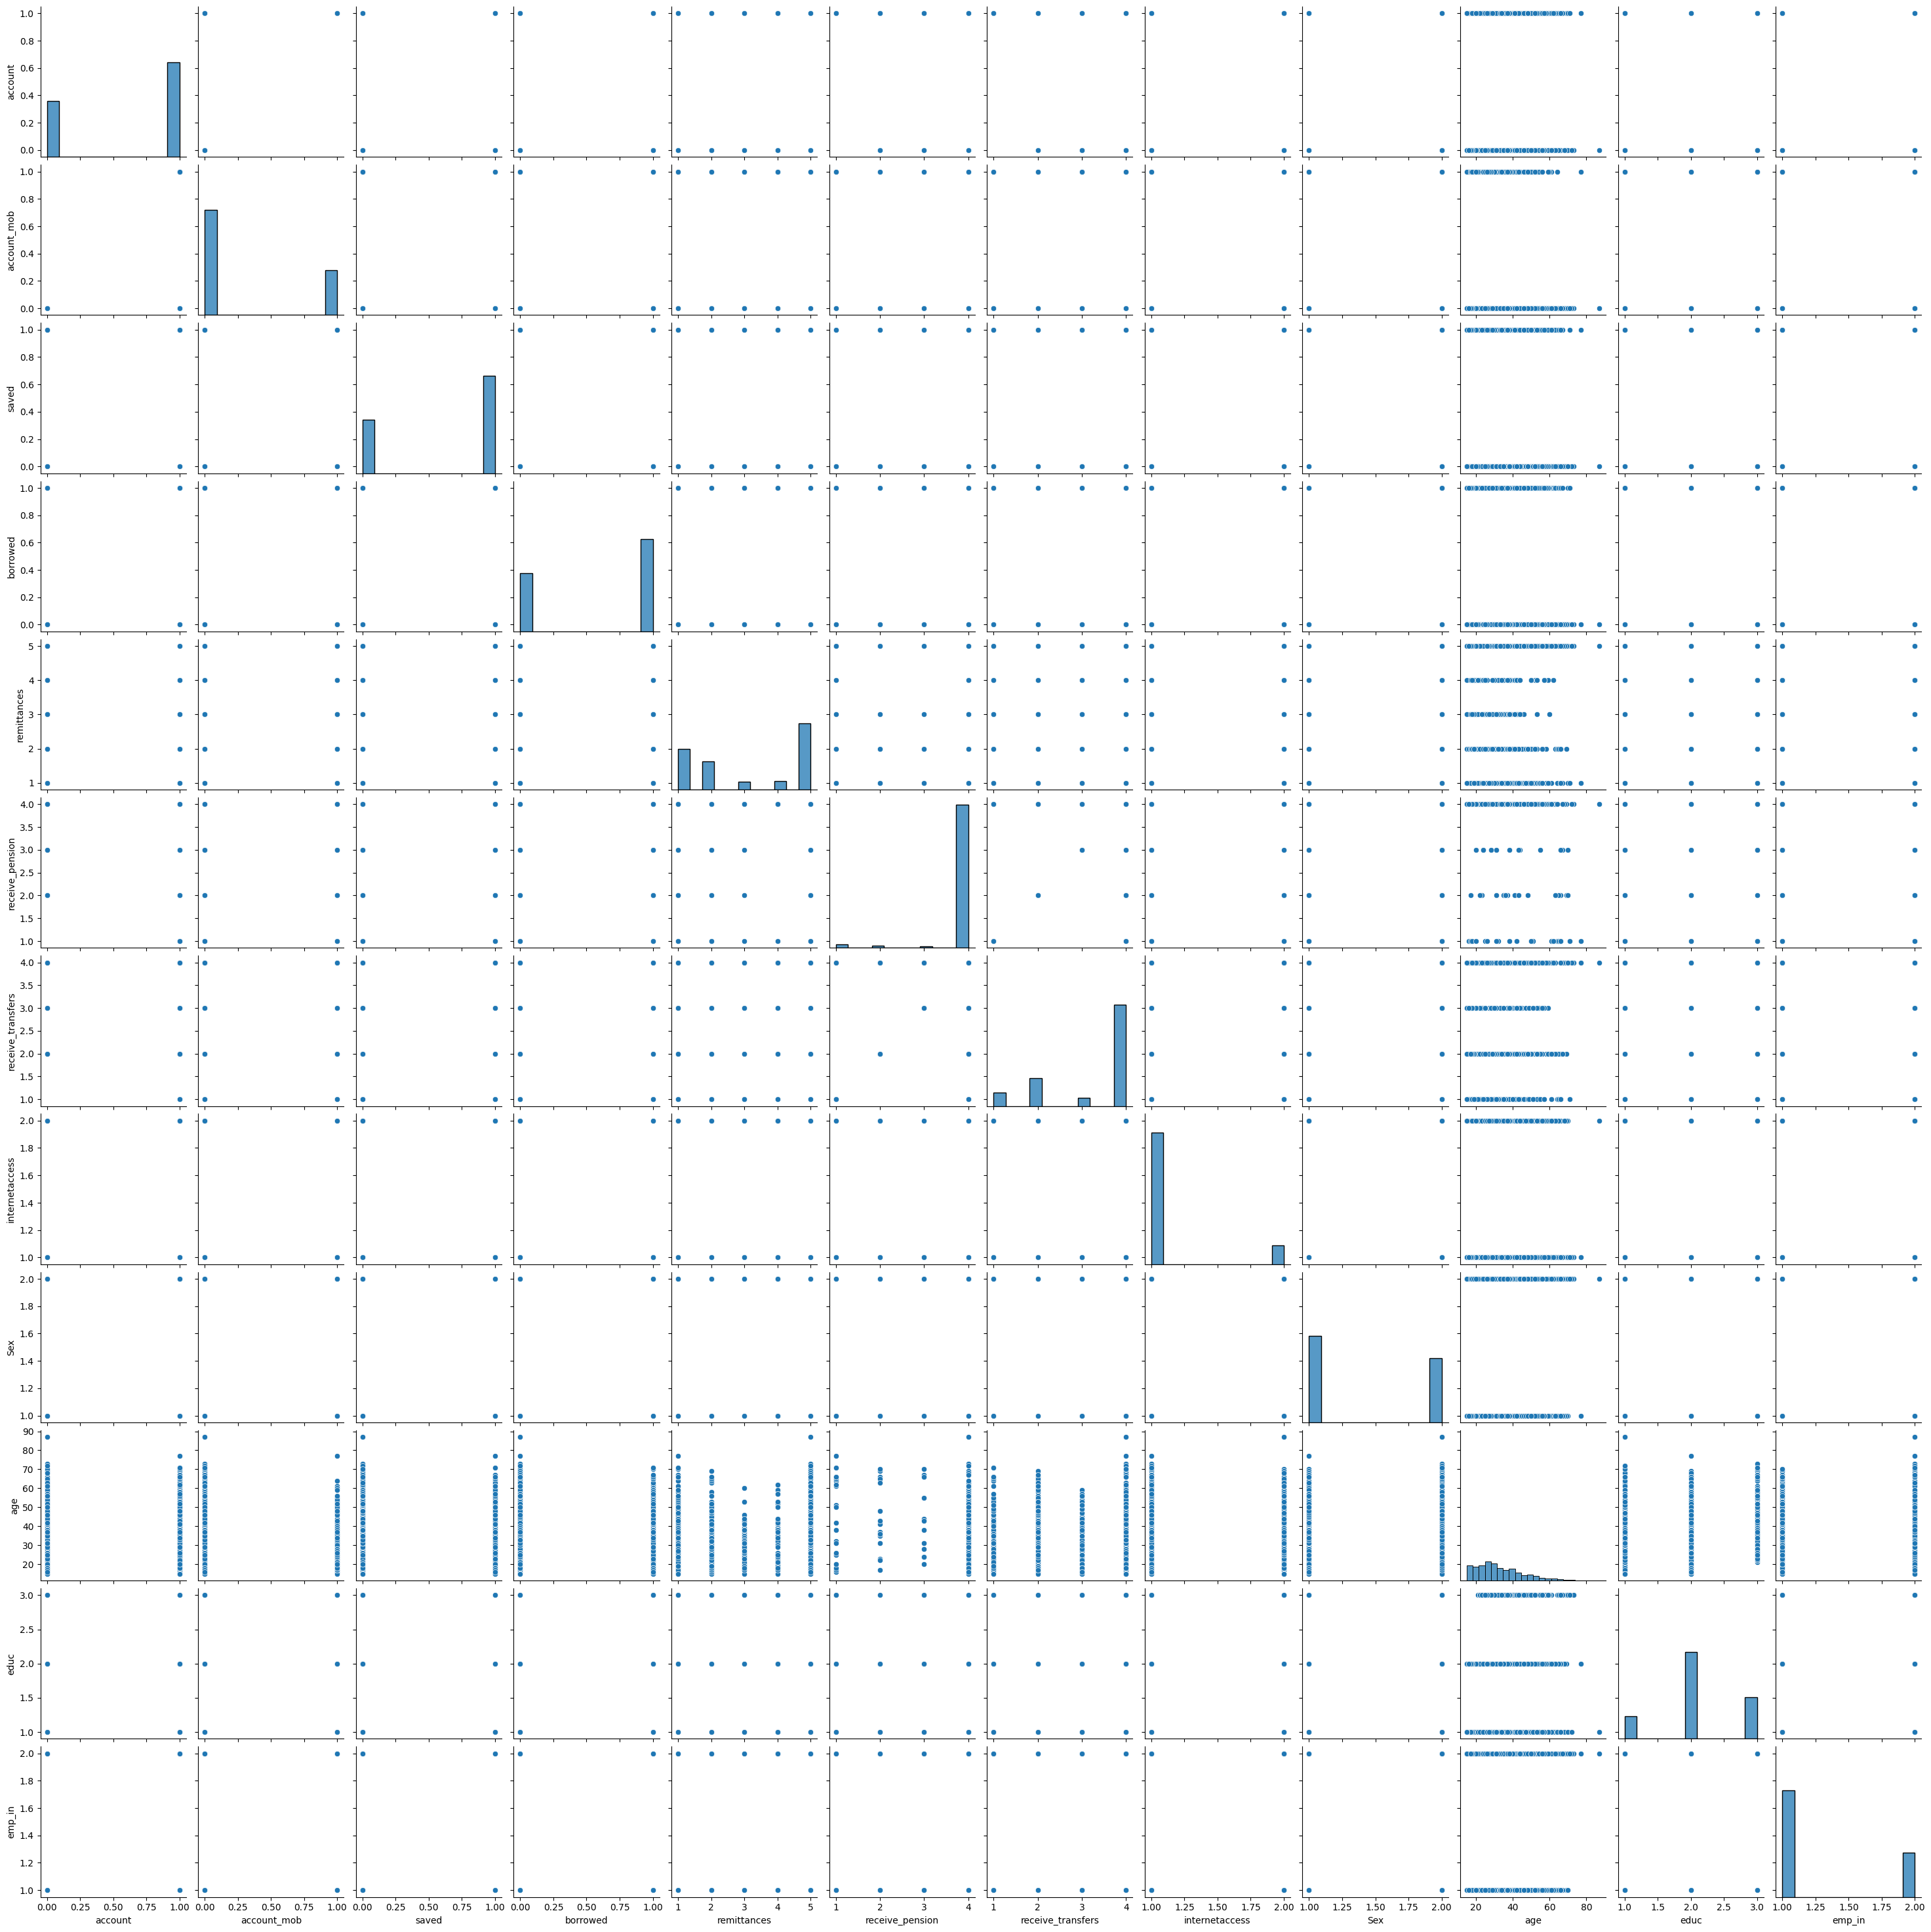

In [32]:
# Pairplot of all features (may be wise to select a few rows instead of all for better readability)
plt.figure(figsize=(20,20))
sns.pairplot(data_with_key_var)
plt.show()

### Creating plots with the weighted means 

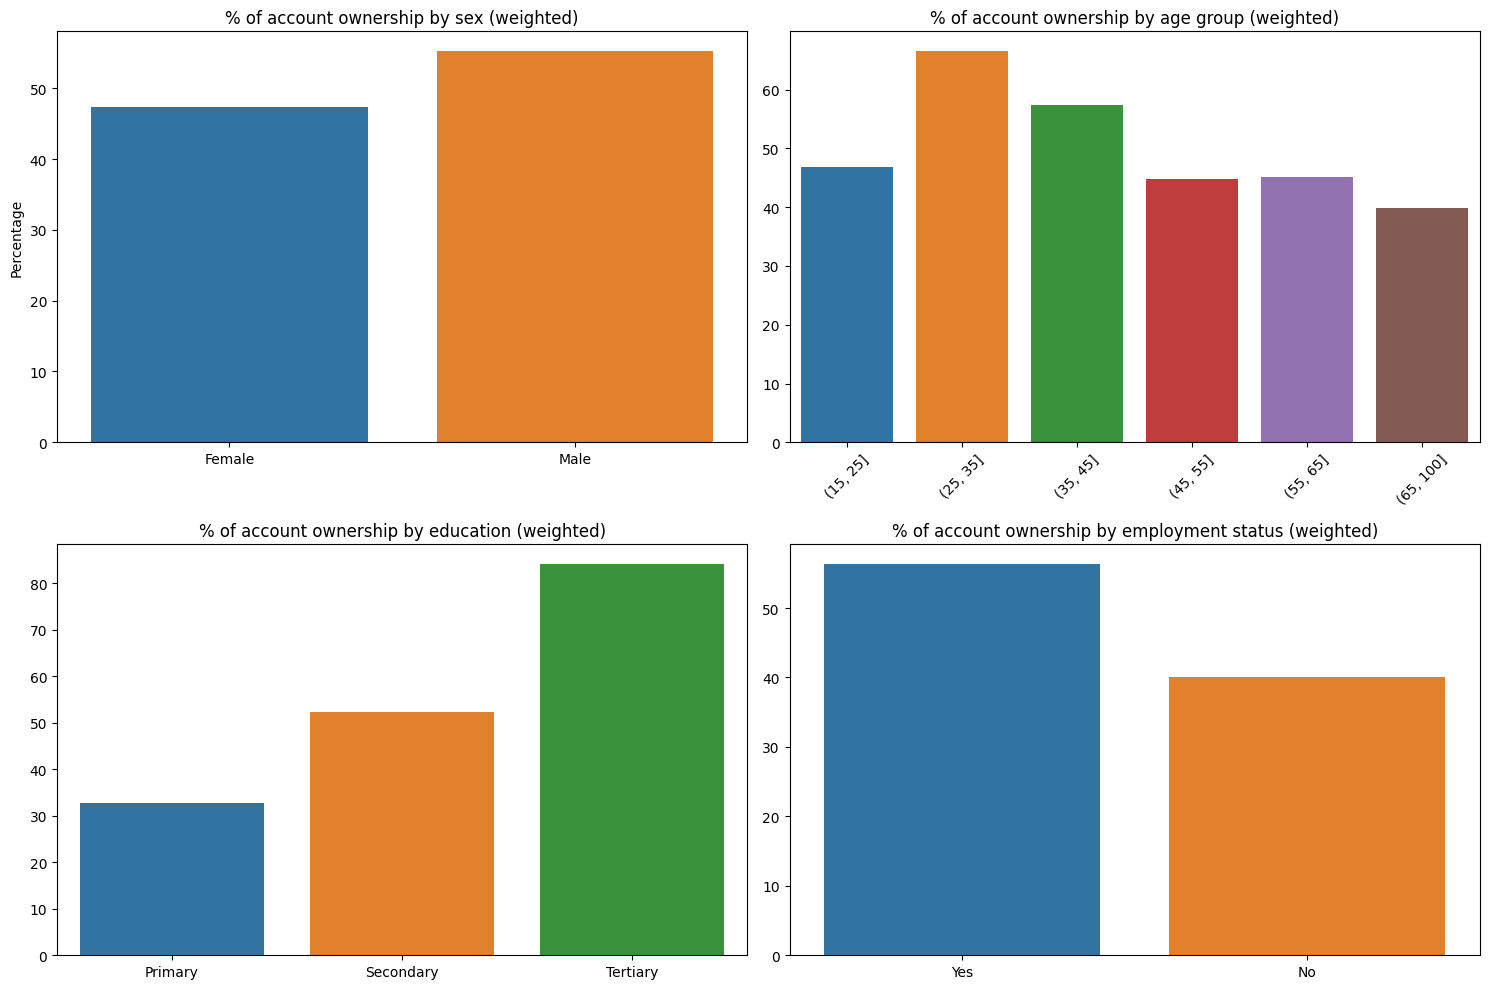

In [41]:
# Dropping all the NA values
data_after_second_cleansing = data_after_second_cleansing.dropna(subset=['account', 'Sex', 'age', 'educ', 'emp_in', 'wgt'])

# Weighted mean function
def weighted_mean(df, group_col, target_col='account'):
    result = {}

    for group, group_df in df.groupby(group_col):
        weights = group_df['wgt']
        values = group_df[target_col]
        weighted_avg = np.average(values, weights=weights) * 100
        result[group] = weighted_avg

    return pd.Series(result)

# Calculate weighted percentages
acc_sex = weighted_mean(data_after_second_cleansing, 'Sex')
acc_age = weighted_mean(data_after_second_cleansing, pd.cut(data_after_second_cleansing['age'], bins=[15, 25, 35, 45, 55, 65, 100]))
acc_edu = weighted_mean(data_after_second_cleansing, 'educ')
acc_emp = weighted_mean(data_after_second_cleansing, 'emp_in')

# Visualization with proper labeling
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Sex plot
sex_labels = {1: 'Female', 2: 'Male'}
sns.barplot(x=acc_sex.index.map(sex_labels),
            y=acc_sex.values,
            ax=axes[0,0],
            order=['Female', 'Male'])
axes[0,0].set_title('% of account ownership by sex (weighted)')
axes[0,0].set_ylabel('Percentage')

# Age plot
sns.barplot(x=acc_age.index.astype(str),
            y=acc_age.values,
            ax=axes[0,1])
axes[0,1].set_title('% of account ownership by age group (weighted)')
axes[0,1].tick_params(axis='x', rotation=45)

# Education plot 
educ_labels = {1: 'Primary', 2: 'Secondary', 3: 'Tertiary'}
sns.barplot(x=acc_edu.index.map(educ_labels),
            y=acc_edu.values,
            ax=axes[1,0],
            order=['Primary', 'Secondary', 'Tertiary'])
axes[1,0].set_title('% of account ownership by education (weighted)')

# Employment plot
emp_labels = {1: 'Yes', 2: 'No'}

sns.barplot(x=acc_emp.index.map(emp_labels),
            y=acc_emp.values,
            ax=axes[1,1],
            order=['Yes', 'No'])
axes[1,1].set_title('% of account ownership by employment status (weighted)')

plt.tight_layout()
plt.show()